# 05 — A Contrasting Discharge (Discharge 2)

This notebook follows the same method but for a different discharge, to demonstrate that the method is capable of distinguishing between standing and travelling waves. We show that:

1. the spectrogram carries two branches plus a distinct post-transition state, so three separate stretches have to be fitted rather than one
2. the unwrapped phase displays a straight ramp across the array instead of the main shot's flat/stepped staircase
3. the standing-wave goodness-of-fit collapses from $r^2 = 0.988$ to $r^2 = 0.713$, with the point cloud actually being a cloud, not a line
4. because the phase ramps, a wavenumber can be read straight off its slope

In [1]:
# Imports

import sys, os
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.signal as sg
import matplotlib.pyplot as plt

from src import config as cfg
from src.math_helpers import load_data, get_reference_spectrogram, _viterbi_ridge
from src import dmd_tracking
from src.dmd_tracking import run_sliding_optdmd, track_mode
from src.spatial_math import spatial_mode_analysis

## 1. Settings for the second shot

`src/config.py` describes Discharge 1 and is left untouched, so this shot's values live in this cell instead. Three of them differ for reasons worth stating:

* `EVAL_TREE_CH_B = 18`: The experimental database stores the pre-computed spectrogram on one channel per (discharge, detector), and it is channel 18 here rather than 25.
* Two search bands instead of one: The branches run at ~275 kHz (lower) and ~342 kHz (upper) over $t \sim 1.7$–7.5 s.
* `MODE_BAND_MARGIN_B = 5e3` and `WIN_B = 1.0e-3`: Halved margin, doubled window. These modes carry several times less energy fraction than the main shot's, so the per-window eigenvector is less well constrained. Tightening to 5 kHz and lengthening the window to 1.0 ms drops ~20% of windows (those where no pole sits near the ridge at all) and takes the window-to-window frequency jitter from ~4.6 kHz to ~2.1 kHz.

The discharge is also split into three phases. A branch has to exist for a fit of it to mean anything, and inspecting the ridges over the spectrogram (§2) shows the lower branch vanishes at $t \sim 7.8$–9.3 s and the upper one descends onto the band floor at $t \sim 9.5$–10.2 s. At $t \sim 10.2$ s the discharge changes character and the two-branch structure is replaced by a broadened ~285–295 kHz band, analysed as its own phase rather than pretending the branches continue through it.

In [2]:
# Second discharge settings (src/config.py is for Discharge 1 and is deliberately not edited)

PID_B = cfg.PID_B # Discharge 2 ID, read from src/local_settings.py 
EVAL_TREE_CH_B = 18       

BANDS_B = {'lower': (195e3, 300e3), # lower branch
           'upper': (300e3, 395e3)} # upper branch

T_MIN_BUFFER_B = 0.9 # s after t_on
T_MAX_BUFFER_B = 0.15 # s after t_off

MODE_BAND_MARGIN_B = 5e3 # Hz, half the main shot's since the branches are only ~76 kHz apart and each is weaker
WIN_B = 1.0e-3 # s, double the main shot's, to better constrain the per-window eigenvector
N_WINDOWS_PHASE_B = 130   

T_TRANSITION = 10.2 # s, where the discharge abruptly changes character

# Stretches over which each branch genuinely exists, set by inspecting the ridges in section 2
PHASES_B = {'lower_A': dict(ref='lower', t=(1.8, 6.4), note='lower branch, clean two-branch phase'),
            'upper_A': dict(ref='upper', t=(1.2, 9.2), note='upper branch, clean two-branch phase'),
            'lower_B': dict(ref='lower', t=(10.4, 16.9), note='post-transition broadened band')}

COL_B = {'lower_A': 'tab:blue', 'upper_A': 'tab:red', 'lower_B': 'tab:green'}

## 2. Reference spectrogram and one Viterbi ridge per branch

In [3]:
def reference_spectrogram_for(ctx, band, eval_tree_ch, t_min_buffer, t_max_buffer,
                              det=cfg.DET, max_df=cfg.STFT_MAX_DF):
    """
    Parameterised version of src.math_helpers.get_reference_spectrogram(), fetching the pre-computed STFT 
    and tracking the dominant ridge inside a single frequency band.

    Parameters:
    - ctx: context dictionary from load_data()
    - band: (f_lo, f_hi) in Hz, the band the ridge tracker is confined to
    - eval_tree_ch: channel the database holds the pre-computed spectrogram on
    - t_min_buffer: s after t_on before the ridge is considered valid
    - t_max_buffer: s after t_off up to which the ridge is considered valid
    - det: detector number (default: cfg.DET)
    - max_df: maximum allowed ridge drift in Hz/s (default: cfg.STFT_MAX_DF)

    Returns:
    - dict with the spectrogram (f, t, Sxx, Sxx_db), the band it was tracked in,
      and the ridge restricted to the valid window (ridge_t_valid, ridge_f_valid)
      
    """
    d = ctx['d']

    f, t, Sxx = d.spectrogram(det=det, ch=eval_tree_ch) # pre-computed STFT
    Sxx_db = 10 * np.log10(Sxx / np.mean(Sxx[1:])) # dB, normalised by the mean of the positive frequencies

    in_band = (f >= band[0]) & (f <= band[1]) # restrict the tracker to this branch's band
    f_b, P = f[in_band], Sxx[in_band]

    # Two-way background normalisation (divide by row median, subtract column median), as in src
    P_row = P / np.median(P, axis=1, keepdims=True)
    logP = np.log(np.clip(P_row, 1e-12, None))
    score = logP - np.median(logP, axis=0, keepdims=True)

    dt_col = float(np.median(np.diff(t)))
    valid = (t >= ctx['t_on'] + t_min_buffer) & (t <= ctx['t_off'] + t_max_buffer)

    ridge_f, _ = _viterbi_ridge(score, f_b, t, dt_col, max_df_per_s=max_df,
                                smooth_s=30e-3, jump_pen=0.005, valid=valid)
    ridge_f_smooth = sg.medfilt(ridge_f, kernel_size=5)

    return dict(f=f, t=t, Sxx=Sxx, Sxx_db=Sxx_db, band=band,
                ridge_t_valid=t[valid], ridge_f_valid=ridge_f_smooth[valid])

In [4]:
# Load both shots and track one ridge per branch on the second

ctx_A = load_data(cfg.PID, cfg.DET) # Discharge 1, the main discharge of notebooks 01-04
ctx_B = load_data(PID_B, cfg.DET) # Discharge 2, this notebook's contrasting discharge

refs_B = {lab: reference_spectrogram_for(ctx_B, band, EVAL_TREE_CH_B,
                                          T_MIN_BUFFER_B, T_MAX_BUFFER_B)
          for lab, band in BANDS_B.items()}

print(f"Discharge 1: dx = {ctx_A['dx_m']*100:.5f} cm, heating {ctx_A['t_on']:.2f}-{ctx_A['t_off']:.2f} s")
print(f"Discharge 2: dx = {ctx_B['dx_m']*100:.5f} cm, heating {ctx_B['t_on']:.2f}-{ctx_B['t_off']:.2f} s")
for lab, r in refs_B.items():
    print(f"  {lab} ridge: {r['ridge_f_valid'].min()/1e3:.0f} - {r['ridge_f_valid'].max()/1e3:.0f} kHz")

Discharge 1: dx = 0.20171 cm, heating 0.01-7.50 s
Discharge 2: dx = 0.21030 cm, heating 0.00-17.01 s
  lower ridge: 207 - 297 kHz
  upper ridge: 300 - 391 kHz


### The labelled spectrogram

Both branches are visible from $t \sim 1$ s. The thin white lines are the raw Viterbi paths over the whole discharge, while the thick coloured segments mark the three stretches actually fitted.

After the dashed line at $t = 10.2$ s the two-branch structure is gone, replaced by a broadened ~285–295 kHz band (fitted as `lower_B`) plus fainter features near 240 and 205 kHz that this notebook does not fit.

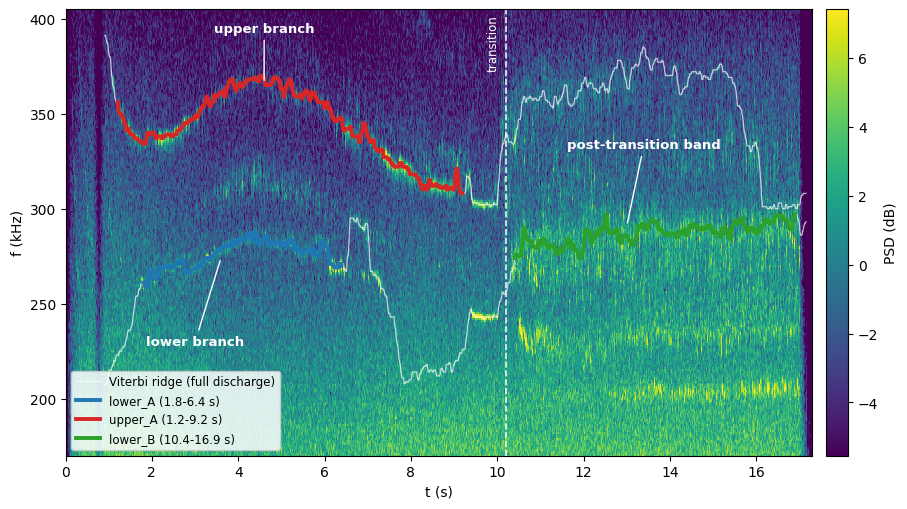

In [5]:
# Labelled spectrogram of the second shot, with the tracked ridges and the fitted phases

f_ax, t_ax, Sxx_B = refs_B['lower']['f'], refs_B['lower']['t'], refs_B['lower']['Sxx']
disp = (f_ax >= 170e3) & (f_ax <= 405e3) # display range spanning both branches
Sdb = 10 * np.log10(Sxx_B[disp] / np.mean(Sxx_B[disp])) # dB relative to the in-band mean

fig, ax = plt.subplots(figsize=(9.8, 5.2))
im = ax.pcolormesh(t_ax, f_ax[disp] / 1e3, Sdb, shading='auto', cmap='viridis',
                   vmin=np.percentile(Sdb, 10), vmax=np.percentile(Sdb, 99.9), rasterized=True)

# Raw Viterbi paths over the whole discharge: thin, to show where they are following nothing
for lab, r in refs_B.items():
    ax.plot(r['ridge_t_valid'], r['ridge_f_valid'] / 1e3, color='w', lw=0.9, alpha=0.7,
            label='Viterbi ridge (full discharge)' if lab == 'lower' else None)

# The stretches actually handed to the sliding fit
for ph, spec in PHASES_B.items():
    r = refs_B[spec['ref']]
    seg = (r['ridge_t_valid'] >= spec['t'][0]) & (r['ridge_t_valid'] <= spec['t'][1])
    ax.plot(r['ridge_t_valid'][seg], r['ridge_f_valid'][seg] / 1e3, lw=2.8, color=COL_B[ph],
            label=f"{ph} ({spec['t'][0]}-{spec['t'][1]} s)")

ax.axvline(T_TRANSITION, color='w', ls='--', lw=1.2, alpha=0.9)
ax.text(T_TRANSITION - 0.15, 402, 'transition', color='w', fontsize=8.5,
        rotation=90, ha='right', va='top')

lbl = dict(color='w', fontsize=9.5, fontweight='bold')
ax.annotate('upper branch', xy=(4.6, 366), xytext=(4.6, 393), ha='center',
            arrowprops=dict(arrowstyle='-', color='w', lw=1.0), **lbl)
ax.annotate('lower branch', xy=(3.6, 274), xytext=(3.0, 228), ha='center',
            arrowprops=dict(arrowstyle='-', color='w', lw=1.0), **lbl)
ax.annotate('post-transition band', xy=(13.0, 291), xytext=(13.4, 332), ha='center',
            arrowprops=dict(arrowstyle='-', color='w', lw=1.0), **lbl)

ax.set_xlim(0, 17.3)
ax.set_ylim(170, 405)
ax.set_xlabel('t (s)')
ax.set_ylabel('f (kHz)')
ax.legend(loc='lower left', fontsize=8.5, framealpha=0.85)
fig.colorbar(im, ax=ax, pad=0.015, label='PSD (dB)')
fig.tight_layout()
plt.show()

## 3. The tracked modes for both shots

In [6]:
# Load (or fit) the tracked modes for both shots

# Discharge 1: the fit of notebook 02, loaded from the same checkpoint it wrote
ref_A = get_reference_spectrogram(ctx_A)
rows_A = run_sliding_optdmd(ctx_A, ref_A,
                            checkpoint_path=os.path.join(cfg.OUT, 'discharge1_dmd_traces.pkl'))
track_A = track_mode(rows_A)

# Discharge 2: one fit per phase
dmd_tracking.MODE_BAND_MARGIN = MODE_BAND_MARGIN_B

tracks_B = {}
for ph, spec in PHASES_B.items():
    t0, t1 = spec['t']
    ctx_phase = dict(ctx_B, t_on=t0 - 0.05, t_off=t1 + 0.05) # run_sliding_optdmd adds +/-0.05 s back
    rows = run_sliding_optdmd(ctx_phase, refs_B[spec['ref']], win=WIN_B,
                              n_windows=N_WINDOWS_PHASE_B,
                              checkpoint_path=os.path.join(cfg.OUT, f'discharge2_{ph}_traces.pkl'))
    tracks_B[ph] = track_mode(rows)

# Averaged spatial profile over the stable middle third of each fit
spatial_A = spatial_mode_analysis(ctx_A, track_A)
spatial_B = {ph: spatial_mode_analysis(ctx_B, tr) for ph, tr in tracks_B.items()}

print(f"{'case':22s} {'windows':>8s} {'f (kHz)':>9s} {'wander (kHz)':>9s} {'energy frac':>12s}")
print(f"{'Discharge 1':22s} {len(track_A['t']):8d} {np.median(track_A['f'])/1e3:9.1f} "
      f"{np.median(np.abs(np.diff(track_A['f'])))/1e3:8.2f} {np.median(track_A['energy_frac']):12.5f}")
for ph, tr in tracks_B.items():
    print(f"{'Discharge 2 ' + ph:22s} {len(tr['t']):8d} {np.median(tr['f'])/1e3:9.1f} "
          f"{np.median(np.abs(np.diff(tr['f'])))/1e3:8.2f} {np.median(tr['energy_frac']):12.5f}")

case                    windows   f (kHz) wander (kHz)  energy frac
Discharge 1                 166     221.1     2.76      0.00295
Discharge 2 lower_A         106     276.8     2.11      0.00040
Discharge 2 upper_A          88     341.4     2.86      0.00048
Discharge 2 lower_B          92     287.1     2.98      0.00081


## 4. Unwrapped eigenvector phase: standing versus travelling

Here we take the averaged complex eigenvector $\phi$ and unwrap $\arg(\phi)$ along the array. A standing wave has one global phase everywhere, so the unwrapped phase is flat, with abrupt $\pi$ steps at the nodes where the real amplitude changes sign. A travelling wave $\propto e^{i k x}$ accumulates phase linearly, so the unwrapped phase is a straight ramp of slope $k$.

Panel (a) is the main shot: flat runs separated by steps, and a straight-line fit that misses badly ($r^2 = 0.474$). Panel (b) is this shot's lower branch: a clean ramp, fitted to $r^2 = 0.997$.

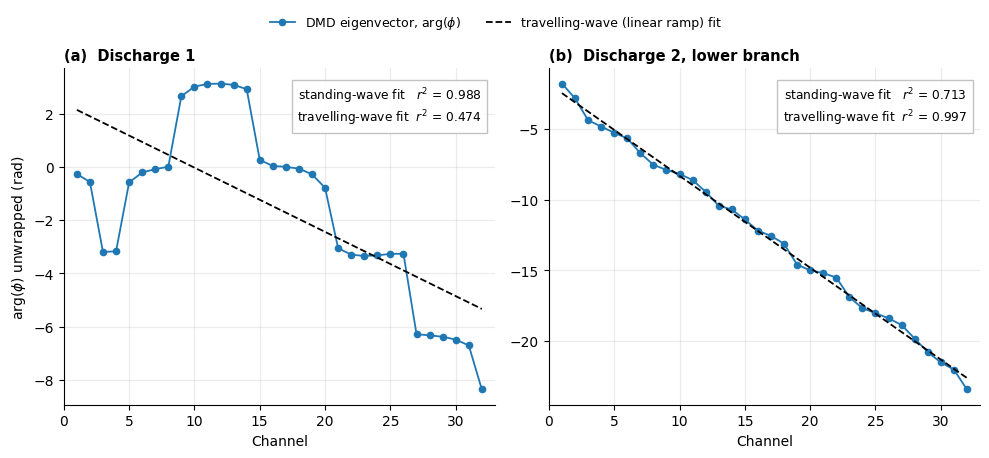

In [7]:
def ramp_fit(phi, x_cm):
    """
    Least-squares straight-line fit to the unwrapped phase of a complex mode vector,
    i.e. the travelling-wave model arg(phi) = k*x + c.

    Parameters:
    - phi: complex spatial mode vector, one entry per channel
    - x_cm: channel positions in cm

    Returns:
    - k: magnitude of the fitted wavenumber in rad/cm
    - r2: fraction of the unwrapped-phase variance the straight line explains
    - u: the unwrapped phase
    - pred: the fitted straight line
    """
    u = np.unwrap(np.angle(phi))
    A = np.vstack([x_cm, np.ones_like(x_cm)]).T
    (k, c), *_ = np.linalg.lstsq(A, u, rcond=None)
    pred = A @ np.array([k, c])
    ss = np.sum((u - u.mean()) ** 2)
    return abs(k), (1 - np.sum((u - pred) ** 2) / ss if ss > 0 else np.nan), u, pred


x_A = np.arange(ctx_A['n_ch']) * ctx_A['dx_m'] * 100 # channel positions in cm, per shot
x_B = np.arange(ctx_B['n_ch']) * ctx_B['dx_m'] * 100
chn = np.arange(1, 33)

k_A, r2ramp_A, u_A, p_A = ramp_fit(spatial_A['phi_mean'], x_A)
k_B, r2ramp_B, u_B, p_B = ramp_fit(spatial_B['lower_A']['phi_mean'], x_B)

fig, ax = plt.subplots(1, 2, figsize=(10.0, 4.3))
panels = [(u_A, p_A, spatial_A['r2_real_avg'], r2ramp_A, '(a)  Discharge 1'),
          (u_B, p_B, spatial_B['lower_A']['r2_real_avg'], r2ramp_B, '(b)  Discharge 2, lower branch')]

for a, (u, pred, r2_standing, r2_travelling, tag) in zip(ax, panels):
    l_dat, = a.plot(chn, u, 'o-', ms=4.5, lw=1.3, color='tab:blue',
                    label=r'DMD eigenvector, $\arg(\phi)$')
    l_fit, = a.plot(chn, pred, 'k--', lw=1.3, label='travelling-wave (linear ramp) fit')
    a.set_title(tag, loc='left', fontweight='bold', fontsize=10.5)
    a.set_xlabel('Channel')
    a.set_xlim(0, 33)
    a.grid(alpha=0.25)
    a.spines[['top', 'right']].set_visible(False)
    a.text(0.97, 0.95, 'standing-wave fit   $r^2$ = %.3f\ntravelling-wave fit  $r^2$ = %.3f'
           % (r2_standing, r2_travelling), transform=a.transAxes, ha='right', va='top',
           fontsize=8.8, bbox=dict(fc='w', ec='0.75', alpha=0.93))

ax[0].set_ylabel(r'$\arg(\phi)$ unwrapped (rad)')
fig.legend(handles=[l_dat, l_fit], loc='upper center', bbox_to_anchor=(0.5, 1.07),
           ncol=2, fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

## 5. Standing wave Goodness-of-Fit calculation

`src.spatial_math._real_mode_fit` treats the 32 complex components of $\phi$ as a point cloud in the $(\mathrm{Re}, \mathrm{Im})$ plane and runs PCA on it. If the mode is a real spatial profile $A(x)$ times a single global phase $\theta_0$, i.e. $\phi_j = A_j e^{i\theta_0}$ with $A_j$ real and signed, then every point lies exactly on the line through the origin at angle $\theta_0$ — the nodes are the points that fall on the negative side of it. Any departure from that model pushes points off the line.

So with $\lambda_\parallel \ge \lambda_\perp$, the eigenvalues of the cloud's covariance matrix, the $r^2$ value can be calculated via

$$r^2 = \frac{\lambda_\parallel}{\lambda_\parallel + \lambda_\perp},$$

which is the fraction of the cloud's variance captured by a single global phase. A perfect standing wave gives 1, while an ideal travelling wave spreads phase uniformly around the circle and gives ~0.5.

The figure below illustrates that calculation: measured $\phi$ in blue, the model prediction (each point's projection onto the fitted axis) as a red ring, and the grey segment between them is the residual whose summed square is $\lambda_\perp$.

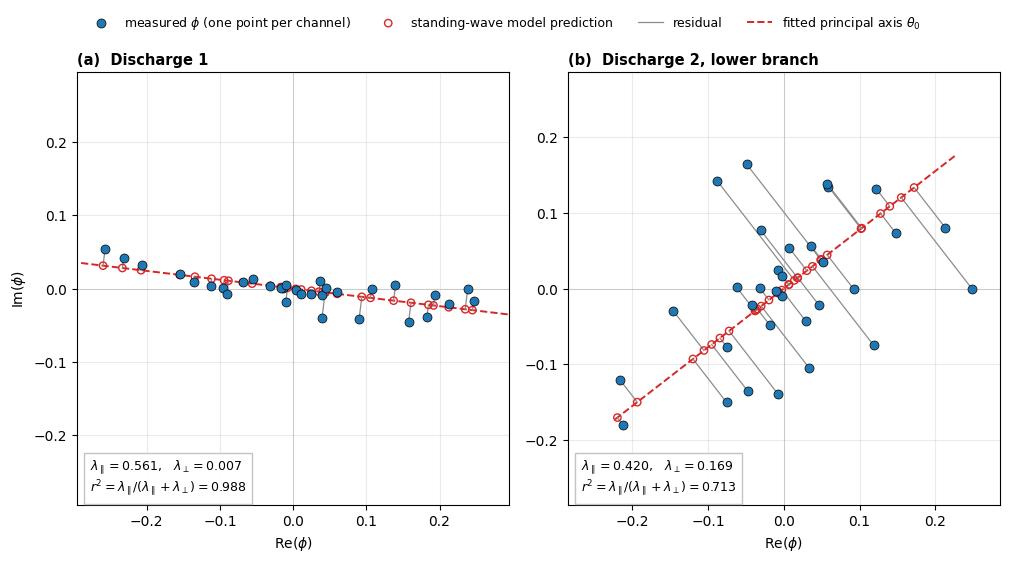

In [10]:
# The standing-wave fit drawn geometrically, for both shots

fig, axes = plt.subplots(1, 2, figsize=(10.2, 5.3))
cases = [(spatial_A, '(a)  Discharge 1'),
         (spatial_B['lower_A'], '(b)  Discharge 2, lower branch')]

for ax_, (sp, tag) in zip(axes, cases):
    phi, theta0 = sp['phi_mean'], sp['theta0_avg']
    re, im = phi.real, phi.imag

    # A is the signed real amplitude: the projection of each point onto the fitted axis
    A = re * np.cos(theta0) + im * np.sin(theta0)
    pred_re, pred_im = A * np.cos(theta0), A * np.sin(theta0)

    # The two PCA eigenvalues
    lam_par = np.sum(A ** 2) # variance along the axis
    lam_perp = np.sum((re - pred_re) ** 2 + (im - pred_im) ** 2) # summed squared residual

    lim = 1.15 * np.max(np.abs(np.concatenate([re, im])))
    span = np.array([-lim, lim])
    l_axis, = ax_.plot(span * np.cos(theta0), span * np.sin(theta0), color='tab:red',
                       lw=1.4, ls='--', zorder=2)
    for x0, y0, x1, y1 in zip(re, im, pred_re, pred_im):
        l_res, = ax_.plot([x0, x1], [y0, y1], color='0.55', lw=0.9, zorder=3) # residuals
    l_mod = ax_.scatter(pred_re, pred_im, facecolor='none', edgecolor='tab:red',
                        s=28, lw=1.0, zorder=4)
    l_dat = ax_.scatter(re, im, color='tab:blue', s=42, edgecolor='k', linewidth=0.5, zorder=5)

    ax_.axhline(0, color='0.8', lw=0.6, zorder=1)
    ax_.axvline(0, color='0.8', lw=0.6, zorder=1)
    ax_.set_xlim(-lim, lim)
    ax_.set_ylim(-lim, lim)
    ax_.set_aspect('equal')
    ax_.set_xlabel(r'$\mathrm{Re}(\phi)$')
    ax_.grid(alpha=0.25)
    ax_.set_title(tag, loc='left', fontweight='bold', fontsize=10.5)
    ax_.text(0.03, 0.03,
             r'$\lambda_\parallel = %.3f$,   $\lambda_\perp = %.3f$' '\n'
             r'$r^2 = \lambda_\parallel / (\lambda_\parallel + \lambda_\perp) = %.3f$'
             % (lam_par, lam_perp, sp['r2_real_avg']),
             transform=ax_.transAxes, fontsize=9, bbox=dict(fc='w', ec='0.75', alpha=0.93))

axes[0].set_ylabel(r'$\mathrm{Im}(\phi)$')
fig.legend(handles=[l_dat, l_mod, l_res, l_axis],
           labels=[r'measured $\phi$ (one point per channel)', 'standing-wave model prediction',
                   'residual', r'fitted principal axis $\theta_0$'],
           loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=4, fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

## 6. Wavenumbers

For the travelling wave phase ramps, $|k_\perp|$ can be found through the slope of that ramp (something that cannot be done from the standing wave phase plots).

Two routes are available:

* the per-window median of $|k|$ over every window of a phase — robust to the minority of windows whose fit lands on the wrong pole
* the ramp slope of the averaged eigenvector `phi_mean` — what §4 plots, but it phase-aligns and averages complex vectors, so when $k$ scatters between windows the average is pulled towards whichever windows happen to align

Panel (a) shows why that distinction is important. Each phase's per-window $|k|$ is peaked, with a scattered minority of windows either side. For `lower_A` the two estimators agree (3.03 vs 3.09). For `upper_A` the averaged eigenvector collapses to 1.30 rad cm$^{-1}$ — a cancellation artefact, not a measurement — while the median sits cleanly at 3.71 in the peak of the distribution. The medians are therefore the quoted values:

| phase | $f$ (kHz) | $\|k_\perp\|$ (rad cm$^{-1}$) | $v_\perp = 2\pi f / k_\perp$ |
|---|---|---|---|
| `lower_A` | 277 | **3.03** | 5.7 km s$^{-1}$ |
| `upper_A` | 341 | **3.71** | 5.8 km s$^{-1}$ |
| `lower_B` | 287 | **3.67** | 4.9 km s$^{-1}$ |

The three land on a common perpendicular phase velocity of ~5–6 km s $^{-1}$ despite spanning 277–341 kHz, which is the signature of one dispersion relation $\omega = v_\perp k_\perp$ rather than three unrelated features.

Panel (b) shows, for each phase, the single window whose $|k|$ is closest to that phase's median, with its ramp fit.

phase         n   f (kHz)   med |k|   avg |k|   med r2  v_perp (km/s)
lower_A     106     276.8     3.034     3.085    0.993           5.73
upper_A      88     341.4     3.705     1.299    0.967           5.79
lower_B      92     287.1     3.673     4.096    0.966           4.91


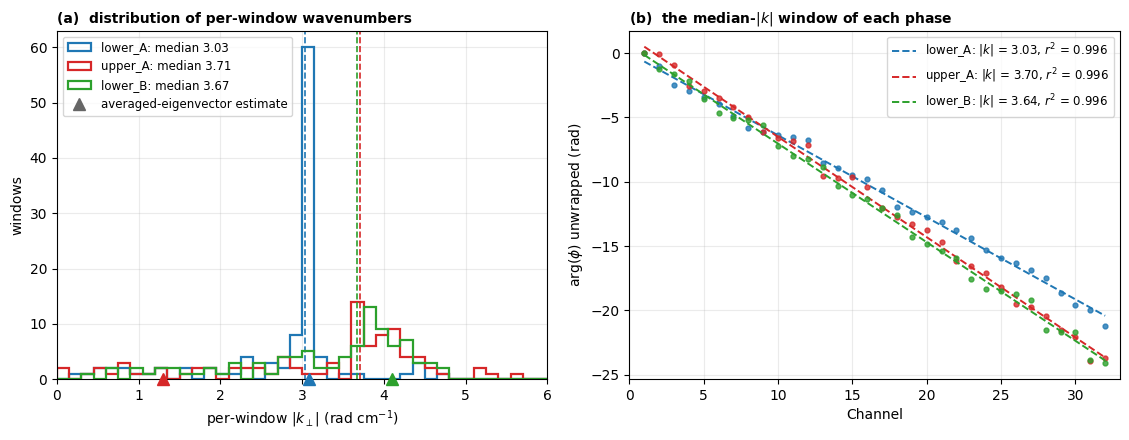

In [11]:
# Per-window wavenumbers, and the median estimator behind the quoted values

print(f"{'phase':10s} {'n':>4s} {'f (kHz)':>9s} {'med |k|':>9s} {'avg |k|':>9s} "
      f"{'med r2':>8s} {'v_perp (km/s)':>14s}")
kres = {}
for ph, tr in tracks_B.items():
    fits = [ramp_fit(tr['phi'][i], x_B) for i in range(tr['phi'].shape[0])]
    ks = np.array([fit[0] for fit in fits]) # per-window wavenumber
    r2s = np.array([fit[1] for fit in fits]) # per-window ramp quality
    k_avg = ramp_fit(spatial_B[ph]['phi_mean'], x_B)[0] # the averaged-eigenvector alternative
    f_med = np.median(tr['f'])
    v_perp = 2 * np.pi * f_med / (np.median(ks) * 100) # k is per cm, so x100 for m/s
    kres[ph] = dict(ks=ks, r2s=r2s, med=np.median(ks), avg=k_avg, f=f_med, v=v_perp, fits=fits)
    print(f'{ph:10s} {len(ks):4d} {f_med/1e3:9.1f} {np.median(ks):9.3f} {k_avg:9.3f} '
          f'{np.median(r2s):8.3f} {v_perp/1e3:14.2f}')

fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.5))

# (a) the distribution each median is taken over, with the averaged-eigenvector value for contrast
bins = np.arange(0, 6.05, 0.15)
for ph in PHASES_B:
    r = kres[ph]
    ax[0].hist(r['ks'], bins=bins, histtype='step', lw=1.6, color=COL_B[ph],
               label=f"{ph}: median {r['med']:.2f}")
    ax[0].axvline(r['med'], color=COL_B[ph], ls='--', lw=1.2)
    ax[0].plot([r['avg']], [0], marker='^', ms=9, color=COL_B[ph], clip_on=False, zorder=5)
ax[0].plot([], [], marker='^', ms=9, ls='none', color='0.4', label='averaged-eigenvector estimate')
ax[0].set_xlabel(r'per-window $|k_\perp|$ (rad cm$^{-1}$)')
ax[0].set_ylabel('windows')
ax[0].set_xlim(0, 6)
ax[0].legend(fontsize=8.5)
ax[0].grid(alpha=0.25)
ax[0].set_title('(a)  distribution of per-window wavenumbers', loc='left',
                fontweight='bold', fontsize=10)

# (b) the window sitting at each phase's median, to confirm the median lands on a good fit
for ph in PHASES_B:
    r = kres[ph]
    j = int(np.argmin(np.abs(r['ks'] - r['med']))) # the median-|k| window
    _, r2, u, pred = r['fits'][j]
    ax[1].plot(chn, u - u[0], 'o', ms=3.5, color=COL_B[ph], alpha=0.8)
    ax[1].plot(chn, pred - u[0], '--', lw=1.4, color=COL_B[ph],
               label=f"{ph}: $|k|$ = {r['ks'][j]:.2f}, $r^2$ = {r2:.3f}")
ax[1].set_xlabel('Channel')
ax[1].set_ylabel(r'$\arg(\phi)$ unwrapped (rad)')
ax[1].set_xlim(0, 33)
ax[1].legend(fontsize=8.5)
ax[1].grid(alpha=0.25)
ax[1].set_title(r'(b)  the median-$|k|$ window of each phase', loc='left',
                fontweight='bold', fontsize=10)

fig.tight_layout()
plt.show()